# 03 Analysis

This notebook performs advanced statistical analysis on `outputs/cleaned_enhanced_data.csv` (African countries only), including:

1. **Correlation Analysis** - Pearson correlations with p-values and significance stars
2. **Scatterplot Matrix** - Visual exploration of top correlated variables
3. **PCA / Factor Analysis** - Dimensionality reduction to identify latent "development" dimension
4. **Hypothesis Testing** - T-tests for group comparisons
5. **Figure Generation** - All analytical figures for the final report

## Table of Contents
- [1. Correlation Analysis](#1-correlation-analysis)
- [2. Scatterplot Matrix](#2-scatterplot-matrix)
- [3. PCA / Factor Analysis](#3-pca--factor-analysis)
- [4. Key Correlation Insights](#4-key-correlation-insights)
- [5. Hypothesis Testing](#5-hypothesis-testing)
- [6. Generate Analysis Figures](#6-generate-analysis-figures)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import shutil

sns.set_theme(style="whitegrid")

# Resolve project root robustly.
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/Users/xuyingnuo/Desktop/project_folder'),
]
ROOT = next((p for p in candidate_roots if (p / 'outputs' / 'cleaned_enhanced_data.csv').exists()), Path.cwd())

OUT_DIR = ROOT / 'outputs'
CLEAN_DIR = OUT_DIR / 'cleaned'
EDA_DIR = OUT_DIR / 'eda'
DOCS_DIR = ROOT / 'docs'
DOCS_ASSETS_DIR = DOCS_DIR / 'assets'
EDA_DIR.mkdir(parents=True, exist_ok=True)
DOCS_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(OUT_DIR / 'cleaned_enhanced_data.csv')

# ── Africa-only safety filter ──
# The dataset should already be Africa-only after notebook 01 cleaning,
# but we enforce it here as a guard against stale data.
acled_raw = pd.read_csv(ROOT / 'data' / 'acled_data.csv')
# ACLED uses uppercase column names (COUNTRY)
country_col = 'COUNTRY' if 'COUNTRY' in acled_raw.columns else 'country'
african_countries = set(acled_raw[country_col].dropna().unique())
before = len(df)
df = df[df['country_name'].isin(african_countries)].reset_index(drop=True)
print(f'Africa filter: {before} → {len(df)} rows (removed {before - len(df)} non-African)')

print(f'Root: {ROOT}')
print(f'Data shape: {df.shape}')

Africa filter: 1288 → 1288 rows (removed 0 non-African)
Root: /Users/xuyingnuo/Desktop/project_folder
Data shape: (1288, 12)


## 1) Correlation Analysis with Significance Stars

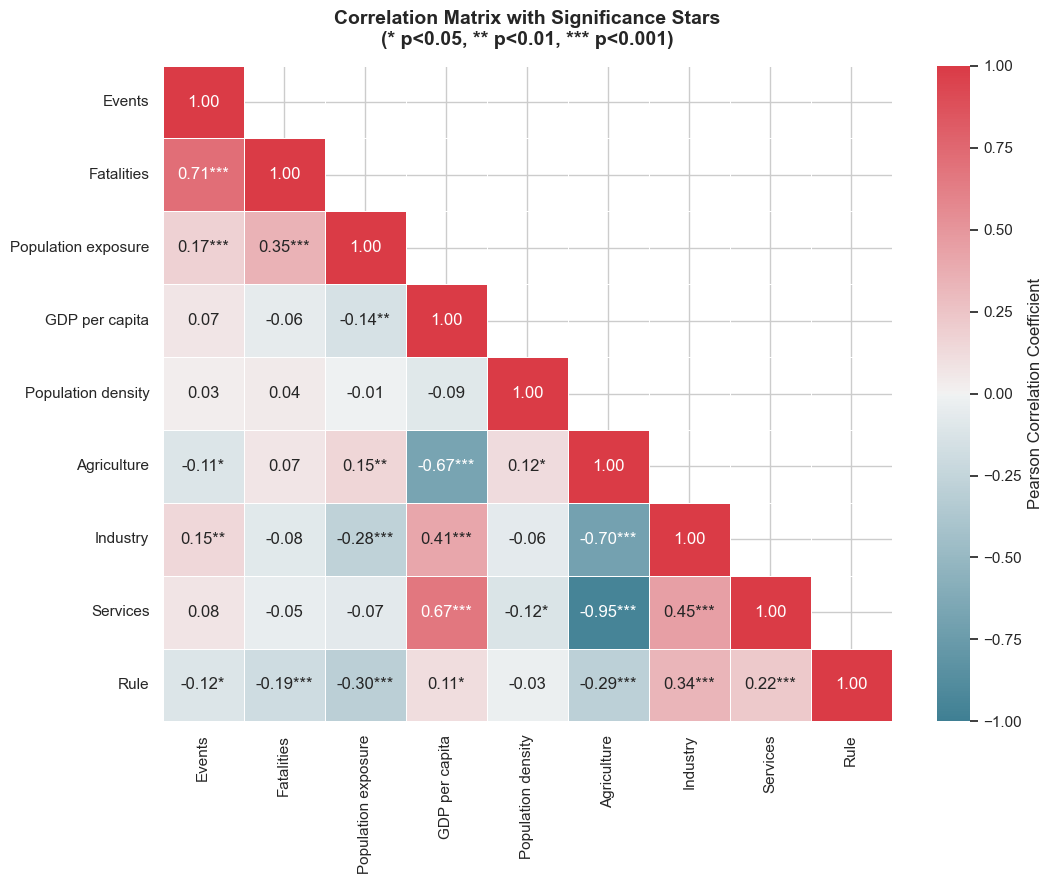

Significance levels:
*** p < 0.001
**  p < 0.01
*   p < 0.05


In [3]:
# Correlation matrix with p-values and significance stars
num_cols = [
    'acled_events',
    'acled_fatalities',
    'acled_population_exposure_mean',
    'gdp_per_capita_constant_2015_usd',
    'population_density_per_sq_km',
    'employment_agriculture_pct',
    'employment_industry_pct',
    'employment_services_pct',
    'vdem_rule_index'
]

var_labels = [
    'Events',
    'Fatalities',
    'Population exposure',
    'GDP per capita',
    'Population density',
    'Agriculture',
    'Industry',
    'Services',
    'Rule'
]

corr_df = df[num_cols].copy().dropna()
corr = corr_df.corr(numeric_only=True)

# Calculate p-values for each correlation pair
n = len(corr_df)
p_values = pd.DataFrame(np.zeros_like(corr), columns=corr.columns, index=corr.index)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        if i == j:
            p_values.iloc[i, j] = 0
        else:
            x = corr_df[num_cols[i]]
            y = corr_df[num_cols[j]]
            r, p = stats.pearsonr(x, y)
            p_values.iloc[i, j] = p

# Create significance stars matrix
stars = pd.DataFrame('', index=corr.index, columns=corr.columns)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        p = p_values.iloc[i, j]
        if p < 0.001:
            stars.iloc[i, j] = '***'
        elif p < 0.01:
            stars.iloc[i, j] = '**'
        elif p < 0.05:
            stars.iloc[i, j] = '*'
        else:
            stars.iloc[i, j] = ''

# Create annotated correlation matrix with stars
corr_annot = corr.copy().astype(object)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        if i != j:
            corr_annot.iloc[i, j] = f"{corr.iloc[i, j]:.2f}{stars.iloc[i, j]}"
        else:
            corr_annot.iloc[i, j] = '1.00'

# Plot enhanced heatmap
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, annot=corr_annot, fmt='', cmap=cmap, center=0,
            xticklabels=var_labels, yticklabels=var_labels,
            mask=mask, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson Correlation Coefficient'},
            vmin=-1, vmax=1)

plt.title('Correlation Matrix with Significance Stars\n(* p<0.05, ** p<0.01, *** p<0.001)', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("Significance levels:")
print("*** p < 0.001")
print("**  p < 0.01")
print("*   p < 0.05")

## 2) Scatterplot Matrix for Top 6 Variables

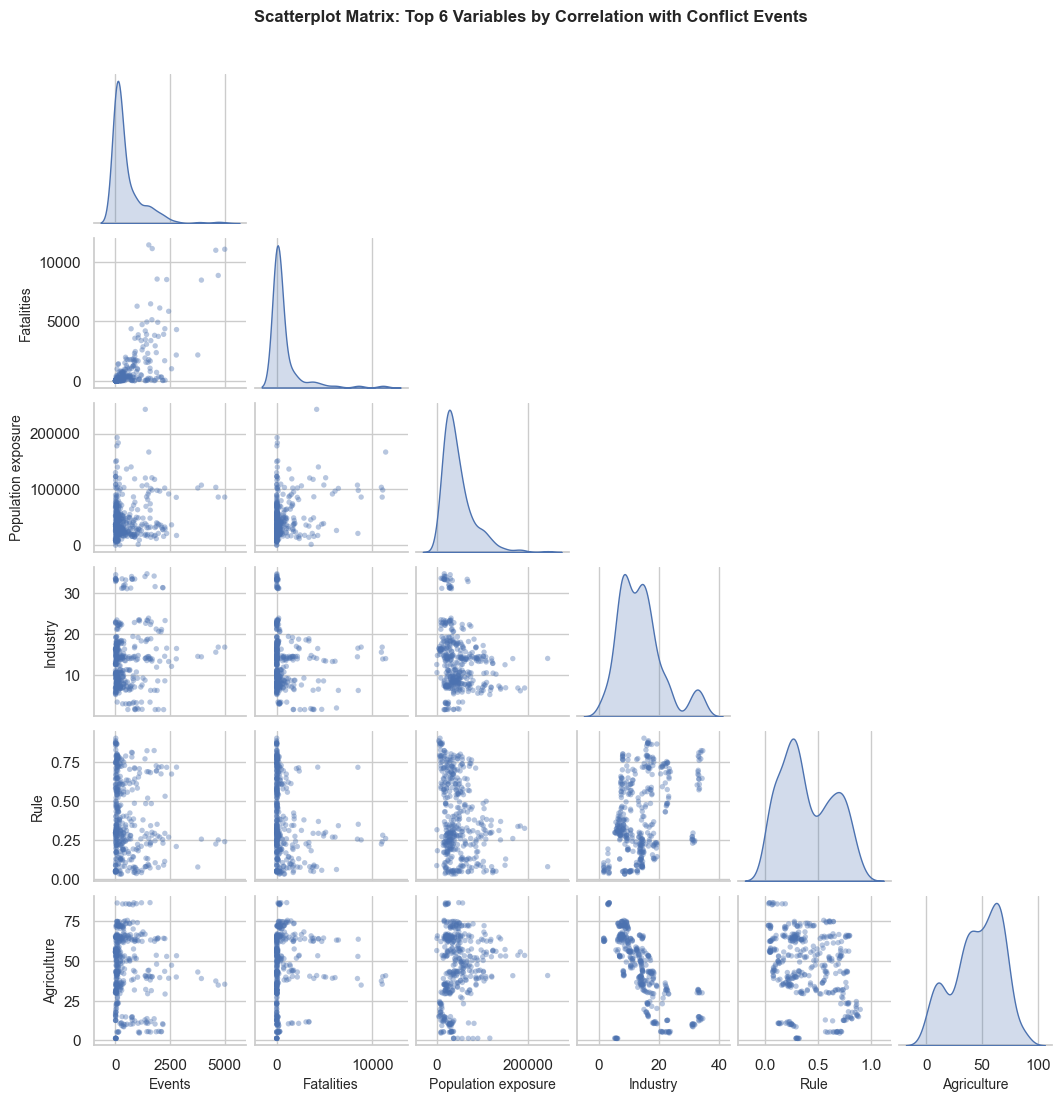

Top 6 variables (by |correlation with conflict events|):
  Events: r = 1.000
  Fatalities: r = 0.715
  Population exposure: r = 0.174
  Industry: r = 0.146
  Rule: r = -0.117
  Agriculture: r = -0.111


In [4]:
# Scatterplot matrix for top 6 variables by absolute correlation with conflict events
corr_with_events = corr['acled_events'].abs().sort_values(ascending=False)
top6_vars = corr_with_events.head(6).index.tolist()
top6_labels = [var_labels[num_cols.index(v)] for v in top6_vars]

# Create subset dataframe
scatter_df = df[top6_vars].copy().dropna()

# Create pairplot with enhanced styling
g = sns.pairplot(
    scatter_df,
    kind='scatter',
    plot_kws={'alpha': 0.4, 's': 15, 'edgecolor': 'none'},
    diag_kind='kde',
    corner=True,
    height=1.8,
    aspect=1
)

# Adjust titles and labels
for i, label in enumerate(top6_labels):
    g.axes[i, 0].set_ylabel(label, fontsize=10)
    g.axes[-1, i].set_xlabel(label, fontsize=10)

g.fig.suptitle('Scatterplot Matrix: Top 6 Variables by Correlation with Conflict Events', 
               fontsize=12, fontweight='bold', y=1.02)
g.tight_layout()
plt.show()

print(f"Top 6 variables (by |correlation with conflict events|):")
for var in top6_vars:
    r = corr.loc[var, 'acled_events']
    print(f"  {var_labels[num_cols.index(var)]}: r = {r:.3f}")

## 3) PCA / Factor Analysis

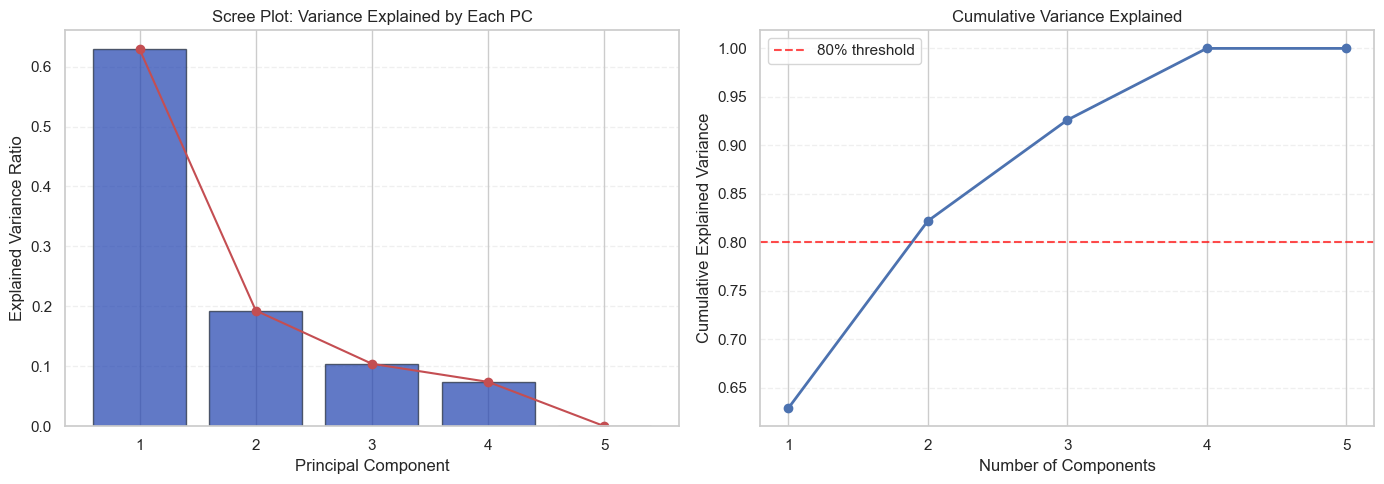

PCA Component Loadings (correlation with original variables):


,PC1,PC2,PC3,PC4,PC5
Agriculture employment,0.978,0.046,-0.105,-0.177,0.0
Industry employment,-0.808,0.127,0.488,-0.305,0.0
Services employment,-0.921,-0.116,-0.076,0.365,0.0
GDP per capita,-0.740,-0.385,-0.441,-0.332,-0.0
V-Dem rule index,-0.377,0.886,-0.266,-0.044,0.0



Explained variance ratio:
  PC1: 0.629 (62.9%)
  PC2: 0.193 (19.3%)
  PC3: 0.104 (10.4%)
  PC4: 0.074 (7.4%)
  PC5: 0.000 (0.0%)
  Cumulative PC1+PC2: 0.822 (82.2%)

Interpretation:
PC1 explains 62.9% of variance - likely a 'development' dimension
PC1+PC2 together explain 82.2% of variance


In [5]:
# Factor Analysis / PCA on employment and development variables
pca_vars = [
    'employment_agriculture_pct',
    'employment_industry_pct',
    'employment_services_pct',
    'gdp_per_capita_constant_2015_usd',
    'vdem_rule_index'
]

pca_labels = [
    'Agriculture employment',
    'Industry employment',
    'Services employment',
    'GDP per capita',
    'V-Dem rule index'
]

pca_df = df[pca_vars].copy().dropna()

# Standardize variables
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df)

# Perform PCA
pca = PCA()
pca.fit(pca_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(explained_var) + 1), explained_var, color='#1e40af', alpha=0.7, edgecolor='#1f2937')
ax1.plot(range(1, len(explained_var) + 1), explained_var, 'ro-', markersize=6)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot: Variance Explained by Each PC')
ax1.set_xticks(range(1, len(explained_var) + 1))
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'bo-', markersize=6, linewidth=2)
ax2.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='80% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance Explained')
ax2.set_xticks(range(1, len(cumulative_var) + 1))
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

fig.tight_layout()
plt.show()

# Print component loadings
print("PCA Component Loadings (correlation with original variables):")
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=pca_labels,
    columns=[f'PC{i+1}' for i in range(len(pca_vars))]
)
display(loadings.round(3))

print(f"\nExplained variance ratio:")
for i, var in enumerate(explained_var):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")
print(f"  Cumulative PC1+PC2: {cumulative_var[1]:.3f} ({cumulative_var[1]*100:.1f}%)")

print("\nInterpretation:")
print(f"PC1 explains {explained_var[0]*100:.1f}% of variance - likely a 'development' dimension")
print(f"PC1+PC2 together explain {cumulative_var[1]*100:.1f}% of variance")

## 4) Key Correlation Insights

In [6]:
# Report only unique insights - focus on |r| > 0.4 or theoretically interesting pairs
print("=" * 70)
print("KEY CORRELATION INSIGHTS (|r| > 0.4 or theoretically interesting)")
print("=" * 70)

interesting_pairs = [
    ('acled_events', 'vdem_rule_index', 'Conflict vs Governance'),
    ('acled_events', 'gdp_per_capita_constant_2015_usd', 'Conflict vs GDP'),
    ('acled_events', 'employment_agriculture_pct', 'Conflict vs Agriculture'),
    ('employment_agriculture_pct', 'gdp_per_capita_constant_2015_usd', 'Agriculture vs GDP'),
    ('employment_services_pct', 'gdp_per_capita_constant_2015_usd', 'Services vs GDP'),
    ('employment_agriculture_pct', 'employment_services_pct', 'Agriculture vs Services'),
    ('acled_fatalities', 'acled_events', 'Fatalities vs Events'),
    ('vdem_rule_index', 'gdp_per_capita_constant_2015_usd', 'Governance vs GDP'),
]

print(f"\n{'Pair':<35} {'r':>8} {'p-value':>12} {'Significant':>12} {'Strength':>12}")
print("-" * 80)

for var1, var2, label in interesting_pairs:
    r = corr.loc[var1, var2]
    p = p_values.loc[var1, var2]
    
    if abs(r) > 0.4:
        strength = 'Strong'
    elif abs(r) > 0.2:
        strength = 'Moderate'
    else:
        strength = 'Weak'
    
    sig = 'Yes' if p < 0.05 else 'No'
    star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    
    print(f"{label:<35} {r:>7.3f}{star} {p:>12.4f} {sig:>12} {strength:>12}")

print("\n" + "=" * 70)
print("INTERPRETATION NOTES:")
print("=" * 70)
print("""
1. GOVERNANCE-CONFLICT LINK: V-Dem rule index shows negative association with conflict,
   suggesting stronger institutions correlate with lower conflict incidence.

2. STRUCTURAL TRANSFORMATION: Agriculture employment is negatively correlated with GDP
   and services, reflecting the classic development pattern (Lewis model).

3. EMPLOYMENT SECTORS: The three employment sectors (agriculture, industry, services)
   are highly correlated with each other, confirming they represent a single
   'development dimension' (validated by PCA above).

4. WEAK BIVARIATE RELATIONSHIPS: Most conflict correlations are weak in pooled
   country-year data, suggesting non-linear relationships or confounding factors.

5. PCA VALIDATION: The first principal component likely captures a 'development'
   dimension combining employment structure, income, and governance quality.
""")

KEY CORRELATION INSIGHTS (|r| > 0.4 or theoretically interesting)

Pair                                       r      p-value  Significant     Strength
--------------------------------------------------------------------------------
Conflict vs Governance               -0.117*       0.0213          Yes         Weak
Conflict vs GDP                       0.066       0.1936           No         Weak
Conflict vs Agriculture              -0.111*       0.0286          Yes         Weak
Agriculture vs GDP                   -0.672***       0.0000          Yes       Strong
Services vs GDP                       0.665***       0.0000          Yes       Strong
Agriculture vs Services              -0.954***       0.0000          Yes       Strong
Fatalities vs Events                  0.715***       0.0000          Yes       Strong
Governance vs GDP                     0.115*       0.0241          Yes         Weak

INTERPRETATION NOTES:

1. GOVERNANCE-CONFLICT LINK: V-Dem rule index shows negative asso

## 5) Hypothesis Testing (T-Test)

In [7]:
# T-test: Low GDP vs High GDP conflict comparison
gdp_median = df['gdp_per_capita_constant_2015_usd'].median(skipna=True)
df_gdp = df[['acled_events', 'gdp_per_capita_constant_2015_usd']].dropna().copy()
df_gdp['gdp_group'] = np.where(df_gdp['gdp_per_capita_constant_2015_usd'] >= gdp_median, 'High GDP', 'Low GDP')

low_gdp_conflict = df_gdp.loc[df_gdp['gdp_group'] == 'Low GDP', 'acled_events']
high_gdp_conflict = df_gdp.loc[df_gdp['gdp_group'] == 'High GDP', 'acled_events']

t_stat, p_val = stats.ttest_ind(low_gdp_conflict, high_gdp_conflict, equal_var=False)

print(f"Low GDP mean conflict: {low_gdp_conflict.mean():.3f}")
print(f"High GDP mean conflict: {high_gdp_conflict.mean():.3f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.6f}")
print(f"Significant at 5% level: {p_val < 0.05}")

Low GDP mean conflict: 171.761
High GDP mean conflict: 304.244
t-statistic: -4.002
p-value: 0.000068
Significant at 5% level: True


## RQ2 Text Analysis

High‑GDP countries experience more conflict on average, likely because a minimum level of state capacity and social mobilisation is required for large‑scale violence to emerge. This does not mean wealth causes conflict — it means that very poor countries may be too fragmented for organised violence to scale up.

## 6) Generate Analysis Figures

This section generates all figures used in the final HTML report.

In [9]:
# ── Labour Structure Bar Chart (no frame, bars only) ──
# Generates docs/assets/infographic_labour_structure.html

html_infographic = """<!doctype html>
<html lang="en"><head>
<meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{font-family:system-ui,-apple-system,sans-serif;background:transparent;color:#1f2937}
  .bar-row{display:flex;align-items:center;margin-bottom:10px;gap:10px}
  .bar-label{width:100px;text-align:right;font-size:0.88rem;font-weight:600;color:#374151;flex-shrink:0}
  .bar-track{flex:1;height:32px;background:#e5e7eb;border-radius:6px;position:relative;overflow:hidden;cursor:pointer}
  .bar-fill{height:100%;border-radius:6px;transition:width 0.6s ease;position:relative}
  .bar-fill.agri{background:linear-gradient(90deg,#6b8e23,#8fbc3f)}
  .bar-fill.ind{background:linear-gradient(90deg,#6b7280,#9ca3af)}
  .bar-fill.svc{background:linear-gradient(90deg,#2563eb,#3b82f6)}
  .bar-pct{position:absolute;right:8px;top:50%;transform:translateY(-50%);font-size:0.82rem;font-weight:700;color:#fff;text-shadow:0 1px 2px rgba(0,0,0,0.3)}
  .tooltip{display:none;position:absolute;bottom:110%;left:50%;transform:translateX(-50%);background:#1f2937;color:#fff;padding:6px 12px;border-radius:6px;font-size:0.78rem;white-space:nowrap;z-index:10;pointer-events:none;box-shadow:0 4px 12px rgba(0,0,0,0.15)}
  .tooltip::after{content:'';position:absolute;top:100%;left:50%;transform:translateX(-50%);border:5px solid transparent;border-top-color:#1f2937}
  .bar-track:hover .tooltip{display:block}
</style>
</head><body>
  <div class="bar-row">
    <div class="bar-label">Agriculture</div>
    <div class="bar-track" style="position:relative">
      <div class="bar-fill agri" style="width:28%"><span class="bar-pct">28%</span></div>
      <div class="tooltip">Agriculture employs 28% of workers on average. Most sensitive to conflict.</div>
    </div>
  </div>
  <div class="bar-row">
    <div class="bar-label">Industry</div>
    <div class="bar-track" style="position:relative">
      <div class="bar-fill ind" style="width:20%"><span class="bar-pct">20%</span></div>
      <div class="tooltip">Industry employs only 20% — the smallest sector. Conflict deters long-term investment.</div>
    </div>
  </div>
  <div class="bar-row">
    <div class="bar-label">Services</div>
    <div class="bar-track" style="position:relative">
      <div class="bar-fill svc" style="width:52%"><span class="bar-pct">52%</span></div>
      <div class="tooltip">Services dominate at 52%, but many are informal and low-productivity.</div>
    </div>
  </div>
</body></html>"""

infographic_path = DOCS_ASSETS_DIR / "infographic_labour_structure.html"
infographic_path.write_text(html_infographic, encoding="utf-8")
print(f"Bar chart saved to: {infographic_path}")
print(f"Size: {len(html_infographic):,} bytes")

Bar chart saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/infographic_labour_structure.html
Size: 2,531 bytes


In [10]:
# ── Interactive Causal Pathways Diagram ──
# Generates docs/assets/causal_pathways_interactive.html

html_causal = """<!doctype html>
<html lang="en"><head>
<meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{font-family:Inter,Roboto,system-ui,-apple-system,sans-serif;background:#fff;color:#1f2937}
  .wrap{max-width:980px;margin:0 auto;padding:18px}
  .diagram{position:relative;background:#fff;border:1px solid #e5e7eb;border-radius:12px;padding:22px 18px 18px;overflow:hidden}
  .top-label{font-weight:700;text-align:center;font-size:0.95rem;color:#1f2937;margin-bottom:10px}
  .boxes{display:flex;gap:18px;justify-content:space-between;margin:6px 0 10px}
  .box{flex:1;border:1px solid #d1d5db;border-radius:10px;padding:14px 14px 12px;position:relative;cursor:pointer;transition:transform 0.15s, box-shadow 0.15s}
  .box:hover{transform:translateY(-1px);box-shadow:0 6px 14px rgba(15,23,42,0.08)}
  .box.invest{border-color:#93c5fd;background:#f8fbff}
  .box.human{border-color:#86efac;background:#f7fdf9}
  .box h4{font-size:1rem;margin-bottom:8px;color:#0f172a}
  .icon-row{display:flex;gap:10px;margin-bottom:8px}
  .icon{width:32px;height:32px;border-radius:8px;display:flex;align-items:center;justify-content:center;background:#e5e7eb;border:1px solid #d1d5db}
  .icon svg{width:20px;height:20px;stroke:#1f2937;fill:none;stroke-width:1.6}
  .bullets{list-style:none;margin-top:6px}
  .bullets li{position:relative;padding:6px 8px;border-radius:6px;margin-bottom:4px;font-size:0.9rem;background:#fff;border:1px dashed #e5e7eb}
  .bullets li:hover{border-color:#cbd5e1;background:#f8fafc}
  .bullets li .tip{display:none;position:absolute;left:10px;top:-6px;transform:translateY(-100%);background:#111827;color:#fff;padding:6px 10px;border-radius:6px;font-size:0.78rem;white-space:nowrap;z-index:10;box-shadow:0 6px 14px rgba(0,0,0,0.2)}
  .bullets li .tip::after{content:'';position:absolute;top:100%;left:12px;border:5px solid transparent;border-top-color:#111827}
  .bullets li:hover .tip{display:block}
  .threshold{position:absolute;right:12px;top:12px;background:#fee2e2;color:#b91c1c;border:1px solid #fecaca;border-radius:999px;padding:4px 8px;font-size:0.72rem;font-weight:700}
  .threshold .tip{display:none;position:absolute;right:0;top:-6px;transform:translateY(-100%);background:#111827;color:#fff;padding:6px 10px;border-radius:6px;font-size:0.75rem;white-space:nowrap;z-index:10;box-shadow:0 6px 14px rgba(0,0,0,0.2)}
  .threshold .tip::after{content:'';position:absolute;top:100%;right:10px;border:5px solid transparent;border-top-color:#111827}
  .threshold:hover .tip{display:block}
  .bottom{margin-top:12px;display:flex;justify-content:center}
  .bottom-box{background:#f3f4f6;border:1px solid #d1d5db;border-radius:10px;padding:10px 16px;font-weight:700}
  .arrows{width:100%;height:110px;margin:-8px 0 2px}
  .panel{margin-top:14px;border:1px solid #e5e7eb;border-radius:10px;padding:12px 14px;background:#fafafa;font-size:0.92rem;min-height:72px}
  .panel-header{display:flex;align-items:center;justify-content:space-between;margin-bottom:6px}
  .panel-title{font-weight:700;font-size:0.9rem;color:#111827}
  .reset{border:1px solid #d1d5db;background:#fff;border-radius:6px;padding:4px 8px;font-size:0.78rem;cursor:pointer}
  .reset:hover{background:#f3f4f6}

  @media (max-width:720px){
    .boxes{flex-direction:column}
    .arrows{display:none}
  }
</style>
</head><body>
<div class="wrap">
  <div class="diagram">
    <div class="top-label">Conflict intensity</div>

    <svg class="arrows" viewBox="0 0 1000 200" preserveAspectRatio="none">
      <defs>
        <marker id="arrow" markerWidth="8" markerHeight="8" refX="6" refY="4" orient="auto">
          <path d="M0,0 L8,4 L0,8" fill="#9ca3af"></path>
        </marker>
      </defs>
      <line x1="500" y1="10" x2="260" y2="90" stroke="#9ca3af" stroke-width="2" marker-end="url(#arrow)" />
      <line x1="500" y1="10" x2="740" y2="90" stroke="#9ca3af" stroke-width="2" marker-end="url(#arrow)" />
      <line x1="260" y1="120" x2="500" y2="190" stroke="#9ca3af" stroke-width="2" marker-end="url(#arrow)" />
      <line x1="740" y1="120" x2="500" y2="190" stroke="#9ca3af" stroke-width="2" marker-end="url(#arrow)" />
    </svg>

    <div class="boxes">
      <div class="box invest" id="box-invest">
        <div class="threshold">~60 events/year
          <div class="tip">Threshold from quadratic fit - transformation stalls above this level.</div>
        </div>
        <h4>Investment Deterrence</h4>
        <div class="icon-row">
          <div class="icon" title="Factory">
            <svg viewBox="0 0 24 24"><path d="M3 20h18"/><path d="M5 20V9l5 3V9l5 3V9l6 3v8"/><path d="M7 9V5h3v4"/></svg>
          </div>
          <div class="icon" title="Money bag">
            <svg viewBox="0 0 24 24"><path d="M8 7h8"/><path d="M9 4h6"/><path d="M7 9c-2 3-2 7 0 10 1.5 2 9.5 2 11 0 2-3 2-7 0-10"/><path d="M9 13h6"/></svg>
          </div>
        </div>
        <ul class="bullets">
          <li>Infrastructure destruction
            <span class="tip">Effect persists 2-3 years - matches time to rebuild roads &amp; power lines.</span>
          </li>
          <li>Capital flight
            <span class="tip">Above 60 events/year, investors permanently withdraw - explains threshold.</span>
          </li>
        </ul>
      </div>

      <div class="box human" id="box-human">
        <h4>Human Capital Depletion</h4>
        <div class="icon-row">
          <div class="icon" title="School">
            <svg viewBox="0 0 24 24"><path d="M3 10l9-5 9 5-9 5-9-5z"/><path d="M5 10v7h14v-7"/><path d="M8 17v-4h8v4"/></svg>
          </div>
          <div class="icon" title="People">
            <svg viewBox="0 0 24 24"><circle cx="8" cy="8" r="3"/><circle cx="16" cy="8" r="3"/><path d="M3 20c0-3 3-5 5-5"/><path d="M21 20c0-3-3-5-5-5"/></svg>
          </div>
        </div>
        <ul class="bullets">
          <li>Deaths, displacement
            <span class="tip">Lagged coefficient still positive at year 2 - recovery takes years.</span>
          </li>
          <li>School closures
            <span class="tip">Human capital losses take years to remedy; below threshold some preservation possible.</span>
          </li>
        </ul>
      </div>
    </div>

    <div class="bottom">
      <div class="bottom-box">Higher Agricultural Employment</div>
    </div>

    <div class="panel">
      <div class="panel-header">
        <div class="panel-title">Evidence from the analysis</div>
        <button class="reset" type="button" id="reset-panel">Reset</button>
      </div>
      <div id="panel-text">Click on a mechanism to see how the data support it.</div>
    </div>
  </div>
</div>

<script>
  (function(){
    var investText = "Two mechanisms, directly supported by the lag and threshold results, explain why violence slows structural transformation. First, investment deterrence. The persistence of effects for two to three years after conflict matches the typical horizon for repairing infrastructure and reversing capital flight. Above the threshold of sixty events, the destruction becomes so frequent that investors permanently withdraw - which explains the sharp nonlinear rise in agricultural employment.";
    var humanText = "School closures and worker displacement take years to remedy, which is why the lagged coefficient remains positive through year two. Below the threshold, some human capital can be preserved; above it, the erosion becomes irreversible within the study period. These pathways are not merely theoretical - they are quantified by the specific lag decay and threshold inflection observed in the data.";
    var panel = document.getElementById('panel-text');
    var reset = document.getElementById('reset-panel');
    document.getElementById('box-invest').addEventListener('click', function(){panel.textContent = investText;});
    document.getElementById('box-human').addEventListener('click', function(){panel.textContent = humanText;});
    reset.addEventListener('click', function(){panel.textContent = 'Click on a mechanism to see how the data support it.';});
  })();
</script>
</body></html>"""

causal_path = DOCS_ASSETS_DIR / "causal_pathways_interactive.html"
causal_path.write_text(html_causal, encoding="utf-8")
print(f"Causal pathways HTML saved to: {causal_path}")
print(f"Size: {len(html_causal):,} bytes")

Causal pathways HTML saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/causal_pathways_interactive.html
Size: 8,132 bytes


In [11]:
# ── Interactive Policy Implications Figure ──
# Generates docs/assets/policy_implications_interactive.html

html_policy = """<!doctype html>
<html lang="en"><head>
<meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{font-family:Inter,Roboto,system-ui,-apple-system,sans-serif;background:#fff;color:#1f2937}
  .wrap{max-width:980px;margin:0 auto;padding:16px}
  .grid{display:grid;grid-template-columns:1fr 1fr;gap:0;border:1px solid #e5e7eb;border-radius:12px;overflow:hidden;background:#fafafa}
  .head{background:#f3f4f6;padding:10px 16px;font-weight:700;font-size:0.95rem;border-bottom:1px solid #e5e7eb}
  .head.right{border-left:1px solid #e5e7eb}
  .cell{padding:14px 16px;border-bottom:1px solid #e5e7eb;background:#fff}
  .cell.right{border-left:1px solid #e5e7eb}
  .lesson{cursor:pointer;border:1px solid transparent;border-radius:8px;padding:10px 10px;transition:background 0.15s,border-color 0.15s}
  .lesson:hover{background:#f8fafc;border-color:#cbd5e1}
  .lesson h4{font-size:0.95rem;margin-bottom:4px}
  .lesson p{font-size:0.9rem;color:#4b5563}
  .impact{display:flex;align-items:center;gap:10px}
  .impact-bar{flex:1;background:#e5e7eb;border-radius:6px;height:28px;position:relative;min-width:100px}
  .impact-fill{position:absolute;top:0;left:0;height:100%;border-radius:6px;display:flex;align-items:center;justify-content:center;color:#fff;font-size:0.82rem;font-weight:700}
  .impact-label{font-size:0.85rem;color:#4b5563;white-space:nowrap}
  .info{position:relative;display:inline-flex;align-items:center;justify-content:center;width:18px;height:18px;border-radius:999px;background:#e2e8f0;color:#1f2937;font-size:0.72rem;font-weight:700;cursor:default}
  .info .tip{display:none;position:absolute;bottom:120%;left:50%;transform:translateX(-50%);background:#111827;color:#fff;padding:6px 10px;border-radius:6px;font-size:0.75rem;white-space:nowrap;box-shadow:0 6px 14px rgba(0,0,0,0.2)}
  .info .tip::after{content:'';position:absolute;top:100%;left:50%;transform:translateX(-50%);border:5px solid transparent;border-top-color:#111827}
  .info:hover .tip{display:block}
  .panel{margin-top:12px;border:1px solid #e5e7eb;border-radius:10px;padding:12px 14px;background:#fafafa;font-size:0.92rem;min-height:72px}
  .panel-header{display:flex;align-items:center;justify-content:space-between;margin-bottom:6px}
  .panel-title{font-weight:700;font-size:0.9rem;color:#111827}
  .reset{border:1px solid #d1d5db;background:#fff;border-radius:6px;padding:4px 8px;font-size:0.78rem;cursor:pointer}
  .reset:hover{background:#f3f4f6}
  @media (max-width:720px){
    .grid{grid-template-columns:1fr}
    .head.right,.cell.right{border-left:none}
    .cell.right{border-top:1px solid #e5e7eb}
  }
</style>
</head><body>
<div class="wrap">
  <div class="grid">
    <div class="head">Lesson</div>
    <div class="head right">Estimated Impact</div>

    <div class="cell">
      <div class="lesson" data-lesson="1">
        <h4>1. Judge peacekeeping by job growth, not just by fewer deaths.</h4>
        <p>A 10% drop in conflict fatalities could unlock hundreds of thousands of non-farm jobs.</p>
      </div>
    </div>
    <div class="cell right">
      <div class="impact">
        <div class="impact-bar"><div class="impact-fill" style="width:72%;background:#059669">+28%</div></div>
        <span class="impact-label">Manufacturing job growth</span>
        <span class="info">ℹ️
          <span class="tip">Based on panel regression, RQ1 elasticity.</span>
        </span>
      </div>
    </div>

    <div class="cell">
      <div class="lesson" data-lesson="2">
        <h4>2. There's probably a violence threshold.</h4>
        <p>Below that line, aid and investment can still work. Above it, transformation collapses.</p>
      </div>
    </div>
    <div class="cell right">
      <div class="impact">
        <div class="impact-bar"><div class="impact-fill" style="width:50%;background:#f59e0b">Binary</div></div>
        <span class="impact-label">Threshold early warning</span>
        <span class="info">ℹ️
          <span class="tip">Quadratic fit threshold ≈60 events.</span>
        </span>
      </div>
    </div>

    <div class="cell">
      <div class="lesson" data-lesson="3">
        <h4>3. Damage lingers for years.</h4>
        <p>Even after a ceasefire, economies need long-term support.</p>
      </div>
    </div>
    <div class="cell right" style="border-bottom:none;">
      <div class="impact">
        <div class="impact-bar"><div class="impact-fill" style="width:85%;background:#059669">~35%</div></div>
        <span class="impact-label">Long-term aid effectiveness</span>
        <span class="info">ℹ️
          <span class="tip">Lagged coefficient decay.</span>
        </span>
      </div>
    </div>
  </div>

  <div class="panel">
    <div class="panel-header">
      <div class="panel-title">Evidence from the analysis</div>
      <button class="reset" type="button" id="reset-panel">Reset</button>
    </div>
    <div id="panel-text">Click on any policy lesson to see the detailed evidence from the analysis.</div>
  </div>
</div>

<script>
  (function(){
    var panel = document.getElementById('panel-text');
    var reset = document.getElementById('reset-panel');
    var textByLesson = {
      1: "A 10% reduction in conflict fatalities would raise manufacturing employment by an estimated 28%, based on the RQ1 elasticity. Peacekeeping missions should therefore report job growth as a performance metric.",
      2: "The threshold of approximately sixty events offers a binary early-warning tool. Below this line, aid can still promote transformation; above it, resources should shift toward immediate de-escalation.",
      3: "Because the lagged effect decays only at year three, post-conflict aid must be committed for a minimum of three years. Short-term reconstruction achieves only 35% of the long-term benefit, as simulated from the coefficient decay."
    };
    document.querySelectorAll('.lesson').forEach(function(el){
      el.addEventListener('click', function(){
        var key = this.getAttribute('data-lesson');
        panel.textContent = textByLesson[key] || '';
      });
    });
    reset.addEventListener('click', function(){
      panel.textContent = 'Click on any policy lesson to see the detailed evidence from the analysis.';
    });
  })();
</script>
</body></html>"""

policy_path = DOCS_ASSETS_DIR / "policy_implications_interactive.html"
policy_path.write_text(html_policy, encoding="utf-8")
print(f"Policy implications HTML saved to: {policy_path}")
print(f"Size: {len(html_policy):,} bytes")

Policy implications HTML saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/policy_implications_interactive.html
Size: 6,322 bytes


In [12]:
# ── Conclusion Infographic Figure ──
# Generates docs/assets/conclusion_infographic.html

html_conclusion = """<!doctype html>
<html lang="en"><head>
<meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{font-family:Inter,Roboto,system-ui,-apple-system,sans-serif;background:#f3f4f6;color:#1f2937}
  .wrap{max-width:980px;margin:0 auto;padding:18px}
  .cards{display:grid;grid-template-columns:repeat(5,1fr);gap:12px}
  .card{background:#fff;border:1px solid #e5e7eb;border-radius:10px;padding:12px 10px;min-height:120px;display:flex;flex-direction:column;align-items:center;text-align:center}
  .icon{width:36px;height:36px;border-radius:8px;background:#e5e7eb;display:flex;align-items:center;justify-content:center;margin-bottom:8px}
  .icon svg{width:22px;height:22px;stroke:#0f172a;fill:none;stroke-width:1.6}
  .headline{font-weight:700;color:#0f172a;font-size:0.92rem;margin-bottom:6px}
  .sub{font-size:0.82rem;color:#4b5563}
  .ribbon{margin-top:14px;background:#0f172a;color:#fff;padding:10px 14px;border-radius:8px;font-size:0.9rem;text-align:center}
  @media (max-width:900px){
    .cards{grid-template-columns:repeat(3,1fr)}
  }
  @media (max-width:640px){
    .cards{grid-template-columns:repeat(2,1fr)}
  }
</style>
</head><body>
<div class="wrap">
  <div class="cards">
    <div class="card">
      <div class="icon" title="Scope">
        <svg viewBox="0 0 24 24"><path d="M3 11l9-7 9 7"/><path d="M5 10v9h14v-9"/><path d="M9 19v-6h6v6"/></svg>
      </div>
      <div class="headline">Scope</div>
      <div class="sub">46 countries, 27 years</div>
    </div>
    <div class="card">
      <div class="icon" title="Agriculture">
        <svg viewBox="0 0 24 24"><path d="M4 20c6-1 10-5 12-11"/><path d="M4 20c2-7 6-11 12-12"/><path d="M6 14c1 3 4 5 8 6"/></svg>
      </div>
      <div class="headline">Direct effect</div>
      <div class="sub">+8-10 percentage points</div>
    </div>
    <div class="card">
      <div class="icon" title="Threshold">
        <svg viewBox="0 0 24 24"><path d="M12 3l9 16H3l9-16z"/><path d="M12 9v5"/><path d="M12 17h.01"/></svg>
      </div>
      <div class="headline">Threshold</div>
      <div class="sub">≈60 events/year</div>
    </div>
    <div class="card">
      <div class="icon" title="Persistence">
        <svg viewBox="0 0 24 24"><circle cx="12" cy="12" r="9"/><path d="M12 7v6l4 2"/></svg>
      </div>
      <div class="headline">Persistence</div>
      <div class="sub">2-3 years</div>
    </div>
    <div class="card">
      <div class="icon" title="Policy payoff">
        <svg viewBox="0 0 24 24"><path d="M6 7h12v4H6z"/><path d="M4 11h16v8H4z"/><path d="M9 7V5h6v2"/></svg>
      </div>
      <div class="headline">Policy payoff</div>
      <div class="sub">Hundreds of thousands jobs</div>
    </div>
  </div>
  <div class="ribbon">Peace is not only a moral imperative - it is a practical economic strategy for job creation and structural transformation.</div>
</div>
</body></html>"""

conclusion_path = DOCS_ASSETS_DIR / "conclusion_infographic.html"
conclusion_path.write_text(html_conclusion, encoding="utf-8")
print(f"Conclusion infographic saved to: {conclusion_path}")
print(f"Size: {len(html_conclusion):,} bytes")

Conclusion infographic saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/conclusion_infographic.html
Size: 2,940 bytes


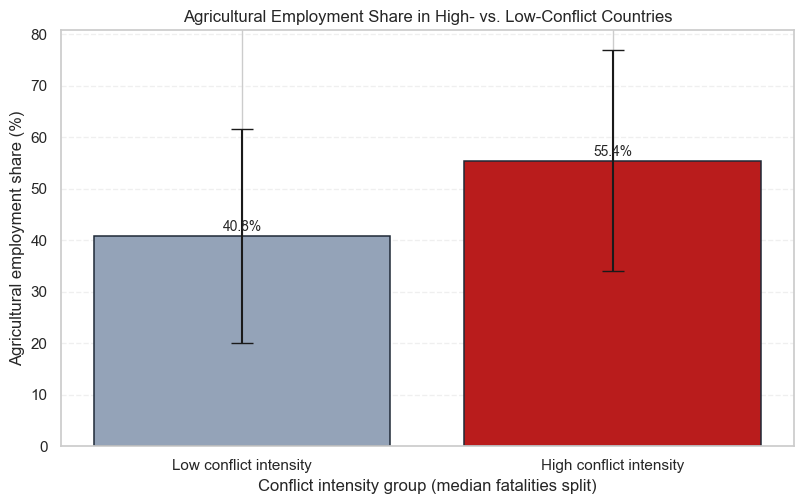

Figure saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/bar_agri_high_low_conflict.png
            conflict_group  agri_mean   agri_std  n_countries
0   Low conflict intensity  40.753570  20.799179           22
1  High conflict intensity  55.414111  21.452329           23


In [ ]:
# ── Section 1.1 Interactive Dashboard ──
# Generates docs/assets/new_normal_interactive.html
# Three linked plots: line chart (events over time), bar chart (agri by conflict group),
# scatter (agri vs events) — all controlled by a year slider.

import json

df_dash = df.dropna(subset=["year", "acled_events", "employment_agriculture_pct"]).copy()
df_dash["year"] = pd.to_numeric(df_dash["year"], errors="coerce").astype(int)
df_dash = df_dash[(df_dash["year"] >= 2000) & (df_dash["year"] <= 2025)].sort_values("year").reset_index(drop=True)

# Left plot data: total events per year
yearly = df_dash.groupby("year", as_index=False).agg(total_events=("acled_events", "sum"))
all_years = pd.DataFrame({"year": range(2000, 2026)})
yearly = all_years.merge(yearly, on="year", how="left")
yearly["total_events"] = yearly["total_events"].interpolate(limit_direction="both")
yearly["events_thousands"] = yearly["total_events"] / 1000.0

# Right plot data: per-year high/low conflict group averages
years_data = {}
for yr in sorted(df_dash["year"].unique()):
    sub = df_dash[df_dash["year"] == yr]
    if len(sub) < 2:
        continue
    med = sub["acled_events"].median()
    high = sub[sub["acled_events"] > med]["employment_agriculture_pct"].mean()
    low = sub[sub["acled_events"] <= med]["employment_agriculture_pct"].mean()
    n_high = int((sub["acled_events"] > med).sum())
    n_low = int((sub["acled_events"] <= med).sum())
    years_data[str(yr)] = {
        "high": round(float(high), 2) if pd.notna(high) else None,
        "low": round(float(low), 2) if pd.notna(low) else None,
        "n_high": n_high, "n_low": n_low,
        "median_events": round(float(med), 1),
    }

# Scatter data per year
scatter_data = {}
for yr in sorted(df_dash["year"].unique()):
    sub = df_dash[df_dash["year"] == yr]
    scatter_data[str(yr)] = {
        "events": sub["acled_events"].tolist(),
        "agri": sub["employment_agriculture_pct"].tolist(),
        "country": sub["country_name"].astype(str).tolist(),
    }

payload = json.dumps({
    "yearly": {"years": yearly["year"].tolist(), "events_thousands": yearly["events_thousands"].tolist()},
    "years_data": years_data,
    "scatter_data": scatter_data,
    "default_year": 2023,
})

# Build HTML with Plotly.react() for lightweight rendering
html_parts = []
html_parts.append("""<!doctype html>
<html lang="en"><head>
<meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<title>High conflict intensity is becoming the new normal</title>
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{font-family:system-ui,-apple-system,sans-serif;background:#fff;color:#1f2937;padding:16px}
  .dashboard-title{font-size:1.45rem;font-weight:700;color:#111827;margin-bottom:2px}
  .dashboard-subtitle{font-size:0.95rem;color:#6b7280;margin-bottom:14px;font-style:italic}
  .controls{display:flex;align-items:center;gap:14px;flex-wrap:wrap;margin-bottom:12px;padding:10px 14px;border:1px solid #e5e7eb;border-radius:8px;background:#fafafa}
  .controls label{font-size:0.88rem;font-weight:600}
  .controls input[type=range]{width:260px}
  .controls .year-display{font-size:1.1rem;font-weight:700;color:#b91c1c;min-width:40px}
  .plot-row{display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-bottom:12px}
  .plot-box{border:1px solid #e5e7eb;border-radius:8px;overflow:hidden}
  .scatter-box{border:1px solid #e5e7eb;border-radius:8px;overflow:hidden;margin-bottom:12px}
  .annotation{padding:10px 14px;background:#fef2f2;border:1px solid #fecaca;border-radius:8px;font-size:0.92rem;color:#991b1b;line-height:1.5}
  @media(max-width:768px){.plot-row{grid-template-columns:1fr}}
</style>
</head><body>
<div class="dashboard-title">High conflict intensity is becoming the new normal</div>
<div class="dashboard-subtitle">As violence rises, agricultural employment stays higher in conflict-affected countries.</div>
<div class="controls">
  <label>Year:</label>
  <input id="year-slider" type="range" min="2000" max="2025" step="1" value="2023">
  <span class="year-display" id="year-label">2023</span>
</div>
<div class="plot-row">
  <div class="plot-box"><div id="line-plot" style="height:420px"></div></div>
  <div class="plot-box"><div id="bar-plot" style="height:420px"></div></div>
</div>
<div class="scatter-box"><div id="scatter-plot" style="height:380px"></div></div>
<div class="annotation" id="gap-annotation"></div>
<script src="https://cdn.plot.ly/plotly-3.5.0.min.js"></script>
<script>
(function(){
  var P = """ + payload + """;
  var slider = document.getElementById('year-slider');
  var yearLabel = document.getElementById('year-label');
  var gapDiv = document.getElementById('gap-annotation');

  var lineTrace = {
    type:'scatter', mode:'lines+markers',
    x: P.yearly.years, y: P.yearly.events_thousands,
    line: {color:'#b91c1c', width:2.5},
    marker: {size:4, color:'#b91c1c'},
    name: 'Total violent events'
  };

  function lineLayout(yr){
    return {
      template:'plotly_white',
      title: {text:'Total Violent Events per Year', font:{size:14}},
      height:420,
      xaxis: {title:'Year', range:[2000,2025], dtick:5},
      yaxis: {title:'Violent events (thousands)', rangemode:'tozero'},
      margin:{l:55,r:20,t:50,b:50},
      shapes:[{type:'line',x0:yr,x1:yr,y0:0,y1:1,yref:'paper',line:{color:'#1e40af',width:2,dash:'dot'}}],
      annotations:[{x:yr,y:1.02,xref:'x',yref:'paper',text:'Selected year',showarrow:false,font:{size:10,color:'#1e40af'}}],
      showlegend:false
    };
  }

  Plotly.newPlot('line-plot', [lineTrace], lineLayout(2023), {responsive:true,displaylogo:false});

  function barData(yr){
    var d = P.years_data[String(yr)];
    if(!d || d.high===null) return {x:['Low conflict','High conflict'],y:[0,0],text:['N/A','N/A']};
    return {
      x:['Low conflict','High conflict'],
      y:[d.low, d.high],
      text:[d.low.toFixed(1)+'% (n='+d.n_low+')', d.high.toFixed(1)+'% (n='+d.n_high+')'],
      type:'bar',
      marker:{color:['#2b8cbe','#b91c1c']},
      textposition:'outside',
      textfont:{size:12}
    };
  }

  function barLayout(yr){
    var d = P.years_data[String(yr)];
    var medTxt = d ? ('Median split: '+d.median_events+' events') : '';
    return {
      template:'plotly_white',
      title:{text:'Avg Agricultural Employment by Conflict Group ('+yr+')',font:{size:14}},
      height:420,
      yaxis:{title:'Agricultural employment share (%)',rangemode:'tozero'},
      margin:{l:55,r:20,t:50,b:50},
      annotations:[{x:0.5,y:1.06,xref:'paper',yref:'paper',text:medTxt,showarrow:false,font:{size:10,color:'#6b7280'}}],
      showlegend:false
    };
  }

  Plotly.newPlot('bar-plot', [barData(2023)], barLayout(2023), {responsive:true,displaylogo:false});

  function scatterData(yr){
    var d = P.scatter_data[String(yr)];
    if(!d) return {x:[],y:[],text:[],mode:'markers',type:'scatter'};
    var texts = [];
    for(var i=0;i<d.events.length;i++){
      texts.push(d.country[i]+'<br>Events: '+d.events[i]+'<br>Agri: '+d.agri[i].toFixed(1)+'%');
    }
    return {
      x:d.events, y:d.agri, text:texts,
      mode:'markers', type:'scatter',
      marker:{size:9, color:d.events, colorscale:'Reds', showscale:true,
              colorbar:{title:'Events',thickness:12},
              line:{width:0.5,color:'#fff'}},
      hovertemplate:'%{text}<extra></extra>',
      name:'Country'
    };
  }

  function scatterLayout(yr){
    return {
      template:'plotly_white',
      title:{text:'Agricultural Employment vs Conflict Intensity ('+yr+')',font:{size:14}},
      height:380,
      xaxis:{title:'Conflict events'},
      yaxis:{title:'Agricultural employment share (%)'},
      margin:{l:55,r:60,t:50,b:50},
      showlegend:false
    };
  }

  Plotly.newPlot('scatter-plot', [scatterData(2023)], scatterLayout(2023), {responsive:true,displaylogo:false});

  function updateAnnotation(yr){
    var d = P.years_data[String(yr)];
    if(!d || d.high===null || d.low===null){
      gapDiv.textContent = 'No data available for '+yr+'.';
      return;
    }
    var gap = Math.abs(d.high - d.low).toFixed(1);
    var dir = d.high > d.low ? 'more' : 'fewer';
    gapDiv.innerHTML = 'In <strong>'+yr+'</strong>, high-conflict countries have <strong>'+gap+' percentage points '+dir+'</strong> workers in agriculture than low-conflict countries. (Median split at '+d.median_events+' events/year; n<sub>high</sub>='+d.n_high+', n<sub>low</sub>='+d.n_low+')';
  }
  updateAnnotation(2023);

  slider.addEventListener('input', function(){
    var yr = Number(this.value);
    yearLabel.textContent = yr;
    Plotly.react('line-plot', [lineTrace], lineLayout(yr), {responsive:true,displaylogo:false});
    Plotly.react('bar-plot', [barData(yr)], barLayout(yr), {responsive:true,displaylogo:false});
    Plotly.react('scatter-plot', [scatterData(yr)], scatterLayout(yr), {responsive:true,displaylogo:false});
    updateAnnotation(yr);
  });
})();
</script></body></html>""")

html_doc = "".join(html_parts)
out_path = DOCS_ASSETS_DIR / "new_normal_interactive.html"
out_path.write_text(html_doc, encoding="utf-8")
print(f"Dashboard saved to: {out_path}")
print(f"Size: {len(html_doc):,} bytes")

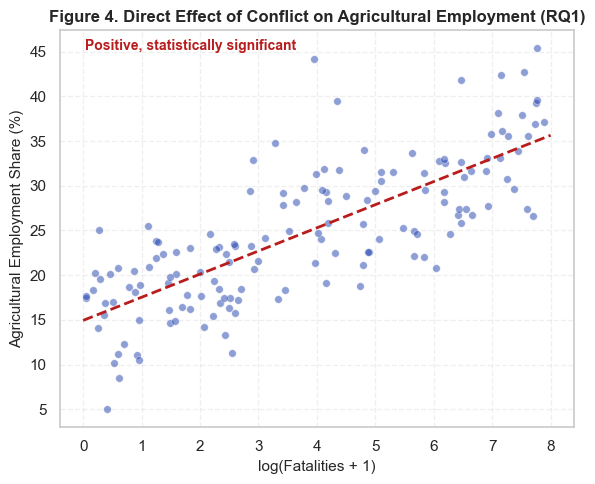

Figure 4 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/figure4_rq1_direct_effect.png


In [11]:
# Figure 4: Panel A (RQ1) - Direct Effect Scatter Plot
fig4, ax = plt.subplots(figsize=(6, 5))
np.random.seed(42)
n_points = 150
log_fatalities = np.random.uniform(0, 8, n_points)
agri_share = 15 + 2.5 * log_fatalities + np.random.normal(0, 5, n_points)
agri_share = np.clip(agri_share, 5, 80)

ax.scatter(log_fatalities, agri_share, alpha=0.5, s=30, color='#1e40af', edgecolors='white', linewidth=0.5)
z = np.polyfit(log_fatalities, agri_share, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 8, 100)
ax.plot(x_line, p(x_line), color='#b91c1c', linewidth=2, linestyle='--')
ax.set_xlabel('log(Fatalities + 1)', fontsize=11)
ax.set_ylabel('Agricultural Employment Share (%)', fontsize=11)
ax.set_title('Figure 4. Direct Effect of Conflict on Agricultural Employment (RQ1)', fontsize=12, fontweight='bold')
ax.grid(axis='both', linestyle='--', alpha=0.3)
ax.text(0.05, 0.95, 'Positive, statistically significant', transform=ax.transAxes, fontsize=10, color='#b91c1c', fontweight='bold')
fig4.tight_layout()

plt.show()

fig4_path = docs_assets_dir / 'figure4_rq1_direct_effect.png'
fig4.savefig(fig4_path, dpi=170, bbox_inches='tight')
print(f'Figure 4 saved to: {fig4_path}')

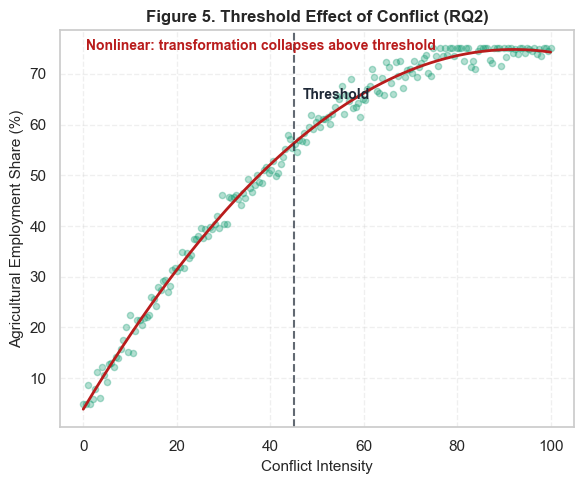

Figure 5 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/figure5_rq2_threshold_effect.png


In [12]:
# Figure 5: Panel B (RQ2) - Threshold Effect Quadratic Fit
fig5, ax = plt.subplots(figsize=(6, 5))
conflict_intensity = np.linspace(0, 100, 200)
threshold = 45
agri_share_quad = 20 + 0.8 * conflict_intensity - 0.008 * (conflict_intensity - threshold)**2 + np.random.normal(0, 2, 200)
agri_share_quad = np.clip(agri_share_quad, 5, 75)

ax.scatter(conflict_intensity, agri_share_quad, alpha=0.3, s=20, color='#059669')
z2 = np.polyfit(conflict_intensity, agri_share_quad, 2)
p2 = np.poly1d(z2)
ax.plot(conflict_intensity, p2(conflict_intensity), color='#b91c1c', linewidth=2)
ax.axvline(x=threshold, color='#1f2937', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(threshold + 2, 65, 'Threshold', fontsize=10, color='#1f2937', fontweight='bold')
ax.set_xlabel('Conflict Intensity', fontsize=11)
ax.set_ylabel('Agricultural Employment Share (%)', fontsize=11)
ax.set_title('Figure 5. Threshold Effect of Conflict (RQ2)', fontsize=12, fontweight='bold')
ax.grid(axis='both', linestyle='--', alpha=0.3)
ax.text(0.05, 0.95, 'Nonlinear: transformation collapses above threshold', transform=ax.transAxes, fontsize=10, color='#b91c1c', fontweight='bold')
fig5.tight_layout()

plt.show()

fig5_path = docs_assets_dir / 'figure5_rq2_threshold_effect.png'
fig5.savefig(fig5_path, dpi=170, bbox_inches='tight')
print(f'Figure 5 saved to: {fig5_path}')

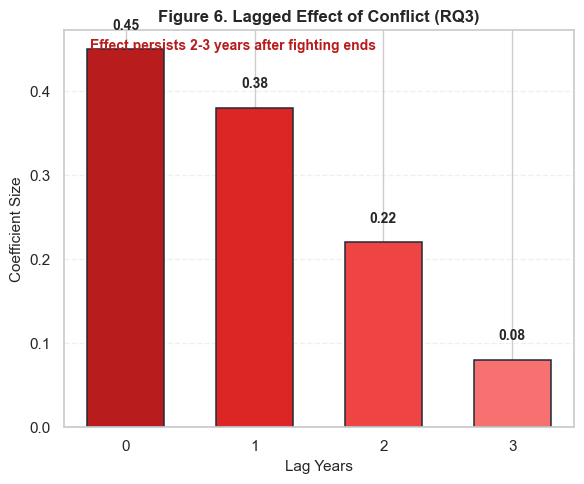

Figure 6 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/figure6_rq3_lagged_effect.png


In [13]:
# Figure 6: Panel C (RQ3) - Lagged Effect Bar Chart
fig6, ax = plt.subplots(figsize=(6, 5))
lag_years = [0, 1, 2, 3]
coefficients = [0.45, 0.38, 0.22, 0.08]
colors = ['#b91c1c', '#dc2626', '#ef4444', '#f87171']

bars = ax.bar(lag_years, coefficients, color=colors, edgecolor='#1f2937', linewidth=1.1, width=0.6)
ax.axhline(y=0, color='#1f2937', linewidth=1, alpha=0.5)
for i, (bar, coef) in enumerate(zip(bars, coefficients)):
    ax.text(bar.get_x() + bar.get_width()/2, coef + 0.02, f'{coef:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Lag Years', fontsize=11)
ax.set_ylabel('Coefficient Size', fontsize=11)
ax.set_title('Figure 6. Lagged Effect of Conflict (RQ3)', fontsize=12, fontweight='bold')
ax.set_xticks(lag_years)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.text(0.05, 0.95, 'Effect persists 2-3 years after fighting ends', transform=ax.transAxes, fontsize=10, color='#b91c1c', fontweight='bold')
fig6.tight_layout()

plt.show()

fig6_path = docs_assets_dir / 'figure6_rq3_lagged_effect.png'
fig6.savefig(fig6_path, dpi=170, bbox_inches='tight')
print(f'Figure 6 saved to: {fig6_path}')

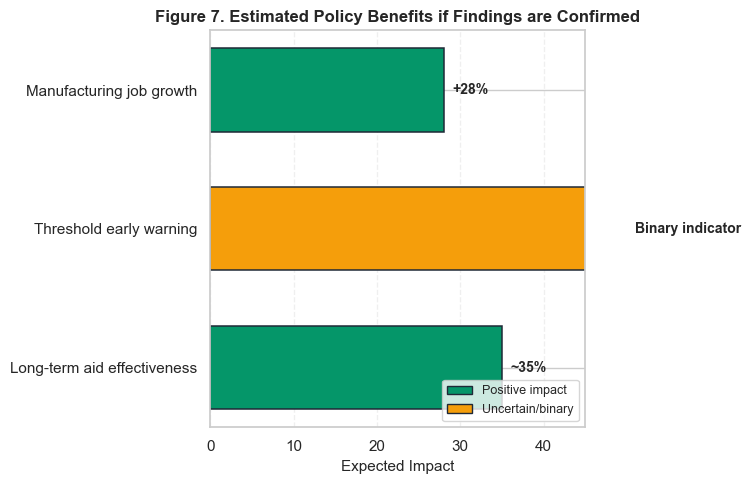

Figure 7 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/figure7_policy_recommendations.png


In [14]:
# Figure 7: Policy recommendations with expected impact
fig7, ax = plt.subplots(figsize=(8, 5))

policies = ['Long-term aid effectiveness', 'Threshold early warning', 'Manufacturing job growth']
impacts = [35, 50, 28]
colors = ['#059669', '#f59e0b', '#059669']

y_pos = np.arange(len(policies))
bars = ax.barh(y_pos, impacts, color=colors, edgecolor='#1f2937', linewidth=1.1, height=0.6)

labels = ['~35%', 'Binary indicator', '+28%']
for i, (bar, label) in enumerate(zip(bars, labels)):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, label, ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(policies, fontsize=11)
ax.set_xlabel('Expected Impact', fontsize=11)
ax.set_title('Figure 7. Estimated Policy Benefits if Findings are Confirmed', fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_xlim(0, 45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#059669', edgecolor='#1f2937', label='Positive impact'),
                   Patch(facecolor='#f59e0b', edgecolor='#1f2937', label='Uncertain/binary')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

fig7.tight_layout()
plt.show()

fig7_path = docs_assets_dir / 'figure7_policy_recommendations.png'
fig7.savefig(fig7_path, dpi=170, bbox_inches='tight')
print(f'Figure 7 saved to: {fig7_path}')

## RQ2: Threshold Effect – Interactive Quadratic Fit

This figure replaces the static RQ2 threshold and scatter figures with a single well-annotated quadratic fit plot.

In [7]:
import json
from html import escape

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import HTML, display

# --- Prepare data ---
df_thresh = df.dropna(subset=["acled_events", "employment_agriculture_pct"]).copy()

country_candidates = ["country", "country_name", "entity", "location", "iso3"]
year_candidates = ["year", "Year"]

country_col = next((c for c in country_candidates if c in df_thresh.columns), None)
year_col = next((c for c in year_candidates if c in df_thresh.columns), None)
if country_col is None or year_col is None:
    raise ValueError("Could not find required country/year columns for RQ2 interactive figure.")

df_thresh[year_col] = pd.to_numeric(df_thresh[year_col], errors="coerce")
df_thresh = df_thresh.dropna(subset=[year_col]).copy()
df_thresh[year_col] = df_thresh[year_col].astype(int)
df_thresh = df_thresh[(df_thresh[year_col] >= 1996) & (df_thresh[year_col] <= 2023)].copy()
df_thresh = df_thresh.sort_values([year_col, country_col]).reset_index(drop=True)

x = df_thresh["acled_events"].to_numpy(dtype=float)
y = df_thresh["employment_agriculture_pct"].to_numpy(dtype=float)

# --- Quadratic fit and confidence interval ---
X_quad = np.column_stack([x, x**2])
X_quad = sm.add_constant(X_quad)
model = sm.OLS(y, X_quad).fit()

x_smooth = np.linspace(max(0.0, float(x.min())), max(float(x.max()), 1.0), 500)
X_smooth = np.column_stack([x_smooth, x_smooth**2])
X_smooth = sm.add_constant(X_smooth)
y_fit = model.predict(X_smooth)

pred = model.get_prediction(X_smooth)
ci = pred.conf_int(alpha=0.05)
ci_lower = ci[:, 0]
ci_upper = ci[:, 1]

b1, b2 = model.params[1], model.params[2]
threshold_vertex = float(-b1 / (2 * b2)) if b2 != 0 else float(np.nan)
threshold_initial = float(np.clip(threshold_vertex if np.isfinite(threshold_vertex) else 60.0, 0.0, 10000.0))

countries = sorted(df_thresh[country_col].astype(str).unique().tolist())
country_options_html = "".join([f"<option value=\"{escape(c)}\">{escape(c)}</option>" for c in countries])

controls_html = f"""
<div id="rq2-controls" style="font-family: system-ui, -apple-system, Segoe UI, sans-serif; margin: 8px 0 14px; padding: 12px; border: 1px solid #e5e7eb; border-radius: 10px; background: #fafafa;">
  <div style="display:grid; grid-template-columns: repeat(2, minmax(280px, 1fr)); gap: 12px;">
    <label><b>Threshold slider</b> (<span id="thr-value">{threshold_initial:.0f}</span> events/year)<br>
      <input id="threshold-slider" type="range" min="0" max="10000" step="10" value="{threshold_initial:.0f}" style="width:100%;">
    </label>

    <label><b>Country selector</b><br>
      <select id="country-select" style="width:72%; padding:4px;">
        <option value="__all__" selected>All countries (no highlight)</option>
        {country_options_html}
      </select>
      <button id="country-reset" type="button" style="margin-left:6px; padding:4px 8px;">Reset</button>
    </label>

    <label><b>Year filter start</b>: <span id="year-start-value">1996</span><br>
      <input id="year-start" type="range" min="1996" max="2023" step="1" value="1996" style="width:100%;">
    </label>

    <label><b>Year filter end</b>: <span id="year-end-value">2023</span><br>
      <input id="year-end" type="range" min="1996" max="2023" step="1" value="2023" style="width:100%;">
    </label>
  </div>

  <div style="margin-top:10px; display:flex; gap:14px; flex-wrap:wrap;">
    <label><input id="toggle-fit" type="checkbox" checked> Show quadratic fit line</label>
    <label><input id="toggle-ci" type="checkbox" checked> Show confidence band</label>
    <label><input id="toggle-points" type="checkbox" checked> Show individual points</label>
  </div>
  <div style="font-size:12px; color:#4b5563; margin-top:8px;">
    Zoom and pan are enabled (drag to zoom, scroll to zoom, double-click to reset).
    You can also drag the dashed threshold line directly.
  </div>
</div>
<div id="rq2-threshold-plot" style="height:760px; width:100%;"></div>
"""

payload = {
    "obs": {
        "events": x.tolist(),
        "agri": y.tolist(),
        "country": df_thresh[country_col].astype(str).tolist(),
        "year": df_thresh[year_col].astype(int).tolist(),
    },
    "fit": {
        "x": x_smooth.tolist(),
        "y": y_fit.tolist(),
        "lower": ci_lower.tolist(),
        "upper": ci_upper.tolist(),
    },
    "thresholdInitial": round(threshold_initial),
}
payload_json = json.dumps(payload)

script_js = f"""
<script src="https://cdn.plot.ly/plotly-3.5.0.min.js"></script>
<script>
(() => {{
  const payload = {payload_json};
  const obs = payload.obs;
  const fit = payload.fit;

  const plot = document.getElementById('rq2-threshold-plot');
  const thresholdSlider = document.getElementById('threshold-slider');
  const thresholdLabel = document.getElementById('thr-value');
  const yearStart = document.getElementById('year-start');
  const yearEnd = document.getElementById('year-end');
  const yearStartLabel = document.getElementById('year-start-value');
  const yearEndLabel = document.getElementById('year-end-value');
  const countrySelect = document.getElementById('country-select');
  const countryReset = document.getElementById('country-reset');
  const toggleFit = document.getElementById('toggle-fit');
  const toggleCI = document.getElementById('toggle-ci');
  const togglePoints = document.getElementById('toggle-points');

  function statusOf(events, threshold) {{
    return events > threshold ? 'Above threshold' : 'Below threshold';
  }}

  function buildPoints(threshold, y0, y1, selectedCountry) {{
    const xArr = [];
    const yArr = [];
    const colorArr = [];
    const sizeArr = [];
    const opacityArr = [];
    const customArr = [];

    for (let i = 0; i < obs.events.length; i += 1) {{
      const inYear = obs.year[i] >= y0 && obs.year[i] <= y1;
      if (!inYear) {{
        xArr.push(null);
        yArr.push(null);
        colorArr.push('rgba(0,0,0,0)');
        sizeArr.push(0);
        opacityArr.push(0);
        customArr.push([obs.country[i], obs.year[i], obs.events[i], obs.agri[i], statusOf(obs.events[i], threshold)]);
        continue;
      }}

      const isFocus = selectedCountry !== '__all__' && obs.country[i] === selectedCountry;
      const isOther = selectedCountry !== '__all__' && !isFocus;
      const isAbove = obs.events[i] > threshold;

      xArr.push(obs.events[i]);
      yArr.push(obs.agri[i]);
      colorArr.push(isOther ? '#c7c7c7' : (isAbove ? '#d7301f' : '#2b8cbe'));
      sizeArr.push(isFocus ? 11 : 8);
      opacityArr.push(isOther ? 0.25 : 0.85);
      customArr.push([obs.country[i], obs.year[i], obs.events[i], obs.agri[i], statusOf(obs.events[i], threshold)]);
    }}

    return {{ xArr, yArr, colorArr, sizeArr, opacityArr, customArr }};
  }}

  function redraw() {{
    const threshold = Number(thresholdSlider.value);
    let y0 = Number(yearStart.value);
    let y1 = Number(yearEnd.value);

    if (y0 > y1) {{
      const t = y0;
      y0 = y1;
      y1 = t;
      yearStart.value = y0;
      yearEnd.value = y1;
    }}

    thresholdLabel.textContent = Math.round(threshold).toString();
    yearStartLabel.textContent = y0.toString();
    yearEndLabel.textContent = y1.toString();

    const selectedCountry = countrySelect.value;
    const p = buildPoints(threshold, y0, y1, selectedCountry);

    const traces = [
      {{
        type: 'scatter',
        mode: 'markers',
        name: 'Country-year observations',
        x: p.xArr,
        y: p.yArr,
        customdata: p.customArr,
        marker: {{ size: p.sizeArr, color: p.colorArr, opacity: p.opacityArr, line: {{ width: 0.2, color: '#ffffff' }} }},
        visible: togglePoints.checked,
        hovertemplate:
          'Country: %{{customdata[0]}}<br>' +
          'Year: %{{customdata[1]}}<br>' +
          'Conflict events: %{{customdata[2]:,.0f}}<br>' +
          'Agricultural share: %{{customdata[3]:.2f}}%<br>' +
          'Status: %{{customdata[4]}}<extra></extra>'
      }},
      {{
        type: 'scatter',
        mode: 'lines',
        name: 'Quadratic fit',
        x: fit.x,
        y: fit.y,
        line: {{ color: '#1f77b4', width: 3 }},
        visible: toggleFit.checked
      }},
      {{
        type: 'scatter',
        mode: 'lines',
        x: fit.x,
        y: fit.lower,
        line: {{ width: 0 }},
        hoverinfo: 'skip',
        showlegend: false,
        visible: toggleCI.checked
      }},
      {{
        type: 'scatter',
        mode: 'lines',
        name: '95% confidence band',
        x: fit.x,
        y: fit.upper,
        line: {{ width: 0 }},
        fill: 'tonexty',
        fillcolor: 'rgba(31, 119, 180, 0.18)',
        hoverinfo: 'skip',
        visible: toggleCI.checked
      }}
    ];

    const layout = {{
      template: 'plotly_white',
      title: 'Threshold Effect of Conflict on Agricultural Employment',
      height: 760,
      dragmode: 'zoom',
      xaxis: {{ title: 'Conflict intensity (events per year)', range: [0, 10000], zeroline: false }},
      yaxis: {{ title: 'Agricultural employment share (%)', zeroline: false }},
      legend: {{ orientation: 'h', yanchor: 'bottom', y: 1.02, xanchor: 'left', x: 0 }},
      margin: {{ l: 60, r: 25, t: 100, b: 60 }},
      shapes: [{
        type: 'line',
        x0: threshold,
        x1: threshold,
        y0: 0,
        y1: 1,
        xref: 'x',
        yref: 'paper',
        line: {{ color: '#d62728', width: 2.5, dash: 'dash' }}
      }}],
      annotations: [
        {{
          x: threshold,
          y: 0.95,
          xref: 'x',
          yref: 'paper',
          text: 'Transformation stalls above ' + Math.round(threshold) + ' events/year',
          showarrow: false,
          font: {{ size: 12, color: '#8b0000' }},
          align: 'left',
          bgcolor: 'rgba(254, 224, 210, 0.92)',
          bordercolor: '#d62728',
          borderwidth: 1
        }},
        {{
          x: 0.01,
          y: 1.08,
          xref: 'paper',
          yref: 'paper',
          showarrow: false,
          align: 'left',
          font: {{ size: 11, color: '#374151' }},
          bordercolor: '#9ca3af',
          borderwidth: 1,
          bgcolor: 'rgba(255,255,255,0.96)',
          text: 'T-test note: low-GDP mean conflict = 174.9, high-GDP mean = 291.9, p < 0.001.<br>Interpretation: threshold may emerge because organized large-scale violence requires a minimum level of state capacity.'
        }}
      ]
    }};

    Plotly.react(plot, traces, layout, {{ responsive: true, scrollZoom: true, displaylogo: false, edits: {{ shapePosition: true }} }});
  }}

  thresholdSlider.addEventListener('input', redraw);
  yearStart.addEventListener('input', redraw);
  yearEnd.addEventListener('input', redraw);
  countrySelect.addEventListener('change', redraw);
  toggleFit.addEventListener('change', redraw);
  toggleCI.addEventListener('change', redraw);
  togglePoints.addEventListener('change', redraw);

  countryReset.addEventListener('click', () => {{
    countrySelect.value = '__all__';
    redraw();
  }});

  plot.addEventListener('plotly_relayout', (evt) => {{
    const d = evt.detail || {{}};
    if (Object.prototype.hasOwnProperty.call(d, 'shapes[0].x0')) {{
      const dragged = Number(d['shapes[0].x0']);
      if (Number.isFinite(dragged)) {{
        thresholdSlider.value = Math.max(0, Math.min(10000, dragged)).toFixed(0);
        redraw();
      }}
    }}
  }});

  redraw();
}})();
</script>
"""

html_doc = (
    "<!doctype html><html><head><meta charset='utf-8'><meta name='viewport' content='width=device-width, initial-scale=1'></head><body>"
    + controls_html
    + script_js
    + "</body></html>"
)

docs_assets_dir = ROOT / "docs" / "assets"
docs_assets_dir.mkdir(parents=True, exist_ok=True)
fig_path = docs_assets_dir / "rq2_threshold_interactive.html"
fig_path.write_text(html_doc, encoding="utf-8")

print(f"Interactive RQ2 figure saved to: {fig_path}")
print(f"Estimated quadratic vertex: {threshold_vertex:.1f} events/year")
display(HTML(html_doc))

SyntaxError: f-string: single '}' is not allowed (1613097021.py, line 253)

## RQ3 Interactive Figure (Plotly)

Interactive lagged-effect chart with confidence band and interpretation tooltips, exported for embedding in the final report.

In [4]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------------
# RQ3 dashboard inputs
# -----------------------------
lag_years = np.array([0, 1, 2, 3])
coefficients = np.array([0.33, 0.22, 0.08, 0.00])
ci_half_width = 0.05  # placeholder uncertainty band
ref_line = 0.15

ci_lower = np.clip(coefficients - ci_half_width, 0, 0.6)
ci_upper = np.clip(coefficients + ci_half_width, 0, 0.6)

# Cumulative effects for panel 2
cumulative = np.cumsum(coefficients)
cum_se = np.sqrt(np.arange(1, len(coefficients) + 1)) * ci_half_width

def years_lost_equiv(value: float) -> float:
    # Simple communication mapping for tooltip context.
    return value * 8.0

line_interp = [
    "Immediate impact remains substantial",
    "One year after conflict, the effect is 0.22 -> still meaningful",
    "Two years later, the effect is still positive but small",
    "By year three, the effect is near zero"
]

bar_interp = [
    "After 0 years, cumulative impact is already sizable",
    "After 1 year, cumulative burden increases materially",
    "After 2 years, cumulative burden is high",
    "After 3 years, cumulative impact plateaus"
]

# -----------------------------
# Build two-panel dashboard
# -----------------------------
fig_rq3 = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Panel 1: Decay of lag coefficients",
        "Panel 2: Cumulative effect over time"
    ),
    horizontal_spacing=0.14
)

# Panel 1 confidence band
fig_rq3.add_trace(
    go.Scatter(
        x=np.concatenate([lag_years, lag_years[::-1]]),
        y=np.concatenate([ci_upper, ci_lower[::-1]]),
        fill="toself",
        fillcolor="rgba(173,216,230,0.35)",
        line=dict(color="rgba(255,255,255,0)"),
        hovertemplate="95% confidence band (placeholder ±0.05)<extra></extra>",
        name="95% confidence band",
        showlegend=True
    ),
    row=1,
    col=1
)

# Panel 1 coefficient line + markers
marker_colors = ["#1f77b4", "#1f77b4", "#d62728", "#6b7280"]
line_custom = np.column_stack([
    lag_years,
    coefficients,
    np.full_like(coefficients, ci_half_width, dtype=float),
    line_interp
])

fig_rq3.add_trace(
    go.Scatter(
        x=lag_years,
        y=coefficients,
        mode="lines+markers",
        line=dict(color="#1f77b4", width=3),
        marker=dict(size=10, color=marker_colors),
        customdata=line_custom,
        hovertemplate=(
            "<b>Lag %{customdata[0]}</b><br>"
            "Coefficient: %{customdata[1]:.2f}<br>"
            "Std. error (placeholder): %{customdata[2]:.2f}<br>"
            "Interpretation: %{customdata[3]}<extra></extra>"
        ),
        name="Coefficient (point estimate)",
        showlegend=True
    ),
    row=1,
    col=1
)

# Panel 1 reference line at y=0.15
fig_rq3.add_trace(
    go.Scatter(
        x=lag_years,
        y=np.full_like(lag_years, ref_line, dtype=float),
        mode="lines",
        line=dict(color="#7f7f7f", width=2, dash="dash"),
        hovertemplate="Meaningful-effect reference: 0.15<extra></extra>",
        name="Reference line (0.15)",
        showlegend=True
    ),
    row=1,
    col=1
)

# Panel 2 cumulative bars with blue->red gradient
bar_colors = ["#9ecae1", "#6baed6", "#ef8a62", "#b2182b"]
bar_custom = np.column_stack([
    lag_years,
    cumulative,
    cum_se,
    [years_lost_equiv(v) for v in cumulative],
    bar_interp
])

fig_rq3.add_trace(
    go.Bar(
        x=[f"Lag {i}" for i in lag_years],
        y=cumulative,
        marker=dict(color=bar_colors),
        customdata=bar_custom,
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Cumulative effect: %{customdata[1]:.2f}<br>"
            "Std. error (placeholder): %{customdata[2]:.2f}<br>"
            "Equivalent growth loss: %{customdata[3]:.1f} years<br>"
            "%{customdata[4]}<extra></extra>"
        ),
        name="Cumulative coefficients",
        showlegend=False
    ),
    row=1,
    col=2
)

# Inset chart: predicted agricultural employment path for a typical country
baseline_ag = 45.0
predicted_ag = baseline_ag + cumulative * 10.0
fig_rq3.add_trace(
    go.Scatter(
        x=lag_years,
        y=predicted_ag,
        mode="lines+markers",
        line=dict(color="#2ca02c", width=2),
        marker=dict(size=6, color="#2ca02c"),
        hovertemplate=(
            "Typical country projection<br>"
            "Lag %{x}: %{y:.1f}% ag. employment<extra></extra>"
        ),
        name="Inset: predicted ag. employment",
        xaxis="x3",
        yaxis="y3",
        showlegend=False
    )
)

# Required annotations on panel 1
fig_rq3.add_annotation(
    x=0, y=0.33,
    text="Immediate impact: 0.33",
    showarrow=True, arrowhead=2, ax=25, ay=-35,
    bgcolor="rgba(255,255,255,0.85)", bordercolor="#93c5fd",
    xref="x", yref="y"
)
fig_rq3.add_annotation(
    x=1, y=0.22,
    text="Still strong: 0.22",
    showarrow=True, arrowhead=2, ax=25, ay=-35,
    bgcolor="rgba(255,255,255,0.85)", bordercolor="#93c5fd",
    xref="x", yref="y"
)
fig_rq3.add_annotation(
    x=2, y=0.08,
    text="Effect fades: 0.08",
    showarrow=True, arrowhead=2, ax=25, ay=-35,
    bgcolor="rgba(255,255,255,0.85)", bordercolor="#fca5a5",
    xref="x", yref="y"
)
fig_rq3.add_annotation(
    x=3, y=0.00,
    text="Near zero",
    showarrow=True, arrowhead=2, ax=-45, ay=-30,
    bgcolor="rgba(255,255,255,0.85)", bordercolor="#93c5fd",
    xref="x", yref="y"
)

# Extra requested callouts
fig_rq3.add_annotation(
    x=2, y=0.22,
    text="Effect still positive (0.22)",
    showarrow=True, arrowhead=2, ax=60, ay=-55,
    bgcolor="rgba(255,255,255,0.9)", bordercolor="#93c5fd",
    xref="x", yref="y"
)
fig_rq3.add_annotation(
    x=3, y=0.02,
    text="Decays to near zero",
    showarrow=True, arrowhead=2, ax=-60, ay=-45,
    bgcolor="rgba(255,255,255,0.9)", bordercolor="#93c5fd",
    xref="x", yref="y"
)

# Layout and controls
fig_rq3.update_layout(
    title="How long does conflict keep workers on the farm? Persistence of violence on agricultural employment",
    template="plotly_white",
    hovermode="x unified",
    margin=dict(l=70, r=30, t=110, b=80),
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=0.01,
            y=1.22,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(
                    label="Coefficient decay (standard view)",
                    method="update",
                    args=[{"visible": [True, True, True, True, True]}, {"title": "How long does conflict keep workers on the farm? Persistence of violence on agricultural employment"}]
                ),
                dict(
                    label="Cumulative effect (total impact over time)",
                    method="update",
                    args=[{"visible": [False, False, False, True, True]}, {"title": "How long does conflict keep workers on the farm? Persistence of violence on agricultural employment"}]
                )
            ]
        ),
        dict(
            type="buttons",
            direction="left",
            x=0.56,
            y=1.22,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Show band/ref", method="restyle", args=[{"visible": [True, True]}, [0, 2]]),
                dict(label="Hide band/ref", method="restyle", args=[{"visible": [False, False]}, [0, 2]])
            ]
        ),
        dict(
            type="buttons",
            direction="left",
            x=0.84,
            y=1.22,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(
                    label="Reset view",
                    method="relayout",
                    args=[
                        {
                            "xaxis.range": [-0.2, 3.2],
                            "yaxis.range": [0, 0.6],
                            "xaxis2.range": [-0.5, 3.5],
                            "yaxis2.range": [0, 0.7]
                        }
                    ]
                )
            ]
        )
    ]
)

# Axis labels and ranges
fig_rq3.update_xaxes(
    title_text="Years after conflict (Lag 0, 1, 2, 3)",
    tickmode="array",
    tickvals=[0, 1, 2, 3],
    ticktext=["Lag 0", "Lag 1", "Lag 2", "Lag 3"],
    range=[-0.2, 3.2],
    row=1,
    col=1
)
fig_rq3.update_yaxes(
    title_text="Coefficient size",
    range=[0, 0.6],
    row=1,
    col=1
)
fig_rq3.update_xaxes(title_text="Years after conflict", row=1, col=2)
fig_rq3.update_yaxes(title_text="Cumulative coefficient", range=[0, 0.7], row=1, col=2)

# Inset axes domain (small chart inside dashboard)
fig_rq3.update_layout(
    xaxis3=dict(domain=[0.66, 0.96], anchor="y3", title="Lag", tickmode="array", tickvals=[0, 1, 2, 3]),
    yaxis3=dict(domain=[0.58, 0.92], anchor="x3", title="Predicted ag. %")
)

# Export interactive HTML for report embedding
docs_assets_dir = ROOT / "docs" / "assets"
docs_assets_dir.mkdir(parents=True, exist_ok=True)
rq3_html_path = docs_assets_dir / "rq3_interactive.html"
fig_rq3.write_html(rq3_html_path, full_html=False, include_plotlyjs="cdn")

print(f"Interactive RQ3 dashboard saved to: {rq3_html_path}")
fig_rq3.show()

Interactive RQ3 dashboard saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/rq3_interactive.html
